# 9.4 Space-Time Point Patterns and Density

**Part:** 9 — Spatio-Temporal Analysis (Chapter 9.4 of 7)

**Dataset:** `crime_data_2018.csv` (14,001 geocoded incidents, UTM 17N per Chapter 9.1's verified fix)

**Focus:** space-only KDE (Part 1, library-supported) applied per time-of-day slice; what a true joint space-time KDE would add

**Library:** `spatialstats.pointpattern.kde` for every density surface in this chapter; no joint space-time density estimator exists in this library

***

## Table of Contents

1.. [Overview](#1.-Overview)
2.. [Python Setup](#2.-Python-Setup)
3.. [Overall Spatial Density](#3.-Overall-Spatial-Density)
4.. [KDE Per Time-of-Day Slice](#4.-KDE-Per-Time-of-Day-Slice)
5.. [Reading the Slices Together](#5.-Reading-the-Slices-Together)
6.. [Separable vs. Product Kernels: What Slicing Does *Not* Give You](#6.-Separable-vs.-Product-Kernels:-What-Slicing-Does-*Not*-Give-You)
7.. [Summary and Conclusions](#7.-Summary-and-Conclusions)
8.. [Resources](#8.-Resources)

***
## 1. Overview

`spatialstats.pointpattern.kde` (Part 1) estimates a purely spatial intensity surface from a single snapshot of
points. This chapter uses it repeatedly — once per time-of-day slice of the 2018 crime data — to build an
approximate picture of how the *spatial* pattern of incidents shifts across the day. This is explicitly **not**
a true joint space-time density estimator; Section 6 explains exactly what that distinction means and why it
matters.

| Step | What we do | Library status |
|------|------------|-----------------|
| Baseline | The full-day spatial KDE, all 14,001 incidents together | ✅ Library-supported (`pointpattern.kde`) |
| Per-slice KDE | Four `pointpattern.kde` calls, one per time-of-day quartile | ✅ Library-supported, applied by hand across slices |
| Reading the slices | Where density concentrates, and how that shifts across the day | Direct comparison of the four surfaces |
| The honest gap | A true joint space-time KDE (separable or product kernel) | 🔲 Not implemented; explained, not built |

***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import MultiPoint

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.pointpattern import PointPattern, Window, kde

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
COLORS = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
          "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

crime = pd.read_csv(DATA / "crime_data_2018.csv")
crime_gdf = gpd.GeoDataFrame(crime, geometry=gpd.points_from_xy(crime["long"], crime["lat"]),
                             crs="EPSG:4326").to_crs("EPSG:32617")   # Chapter 9.1's verified fix
crime["x_utm"] = crime_gdf.geometry.x
crime["y_utm"] = crime_gdf.geometry.y

window_poly = MultiPoint(list(zip(crime["x_utm"], crime["y_utm"]))).convex_hull.buffer(500)
window = Window(window_poly)
print(f"spatialstats : version {spatialstats.__version__}")
print(f"{len(crime):,} incidents, shared analysis window built once for every KDE in this chapter")

spatialstats : version 0.2.0
14,001 incidents, shared analysis window built once for every KDE in this chapter


***
## 3. Overall Spatial Density

A baseline: the full-day spatial intensity surface, every incident type and hour pooled together.

bandwidth (Scott's rule): 580.8 m


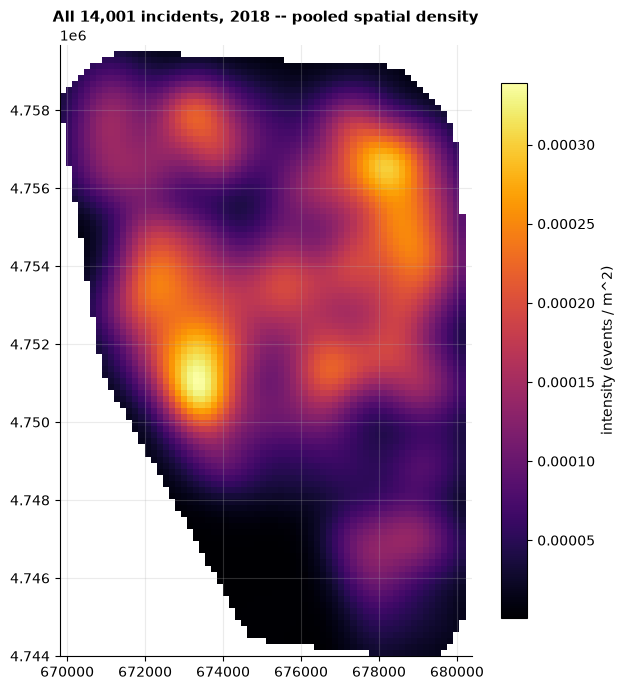

In [2]:
pp_all = PointPattern(crime[["x_utm", "y_utm"]].to_numpy(), window=window)
kde_all = kde(pp_all, bandwidth="scott", grid_size=100)
print(f"bandwidth (Scott's rule): {kde_all.bandwidth:.1f} m")

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(kde_all.density, extent=kde_all.extent, origin="lower", cmap="inferno")
plt.colorbar(im, ax=ax, label="intensity (events / m^2)", fraction=0.046)
ax.set_title(f"All {len(crime):,} incidents, 2018 -- pooled spatial density")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("kde_all.png", dpi=100, bbox_inches="tight")
plt.show()

***
## 4. KDE Per Time-of-Day Slice

`hour_of_day` in this file runs 1-12, not the usual 0-23 — the file does not document which convention this is
(two 12-hour blocks collapsed together, or something else), so this chapter treats it only as an **ordinal
time-of-day label**, split into four roughly-equal quartile groups, without asserting a specific clock-hour
interpretation it cannot verify.

In [3]:
print(crime["hour_of_day"].value_counts().sort_index())

bins = {"1-3": (1, 3), "4-6": (4, 6), "7-9": (7, 9), "10-12": (10, 12)}
kde_by_slice = {}
for label, (lo, hi) in bins.items():
    sub = crime[(crime["hour_of_day"] >= lo) & (crime["hour_of_day"] <= hi)]
    pp = PointPattern(sub[["x_utm", "y_utm"]].to_numpy(), window=window)
    kde_by_slice[label] = kde(pp, bandwidth="scott", grid_size=100)
    print(f"hour_of_day {label}: n={len(sub):,}  bandwidth={kde_by_slice[label].bandwidth:.1f} m")

hour_of_day
1     1076
2     1010
3     1070
4     1016
5     1007
6      939
7      893
8     1145
9     1125
10    1186
11    1217
12    2317
Name: count, dtype: int64
hour_of_day 1-3: n=3,156  bandwidth=739.8 m
hour_of_day 4-6: n=2,962  bandwidth=748.7 m
hour_of_day 7-9: n=3,163  bandwidth=752.9 m
hour_of_day 10-12: n=4,720  bandwidth=695.5 m


The `hour_of_day=12` bucket has roughly double the count of any other single value — worth flagging honestly
rather than silently absorbing into a quartile bin: it may be a genuinely busier period, or it may be a
catch-all/default value in how this field was recorded. Either way, the 10-12 quartile below should be read with
that imbalance in mind.

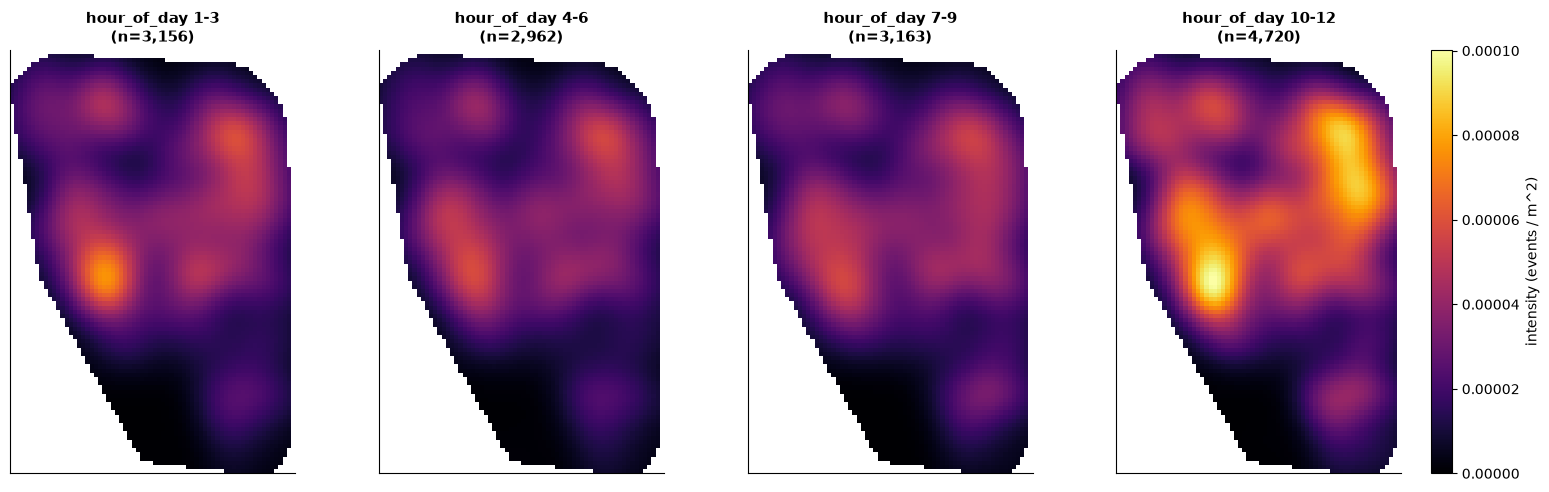

In [4]:
vmax = max(np.nanmax(r.density) for r in kde_by_slice.values())
fig, axes = plt.subplots(1, 4, figsize=(19, 5.5))
for ax, (label, res) in zip(axes, kde_by_slice.items()):
    im = ax.imshow(res.density, extent=res.extent, origin="lower", cmap="inferno", vmin=0, vmax=vmax)
    ax.set_title(f"hour_of_day {label}\n(n={res.n_events:,})")
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, label="intensity (events / m^2)", fraction=0.02, pad=0.02)
plt.savefig("kde_by_slice.png", dpi=100, bbox_inches="tight")
plt.show()

***
## 5. Reading the Slices Together

All four panels share the same colour scale (the maximum density across all slices), so their peak heights are
directly comparable, not just their shapes.

In [5]:
for label, res in kde_by_slice.items():
    peak_idx = np.unravel_index(np.nanargmax(res.density), res.density.shape)
    x0, x1, y0, y1 = res.extent
    xs = np.linspace(x0, x1, res.density.shape[1])
    ys = np.linspace(y0, y1, res.density.shape[0])
    peak_x, peak_y = xs[peak_idx[1]], ys[peak_idx[0]]
    print(f"hour_of_day {label}: peak density = {np.nanmax(res.density):.2e} at ({peak_x:,.0f}, {peak_y:,.0f})")

hour_of_day 1-3: peak density = 7.66e-05 at (673,279, 4,751,365)
hour_of_day 4-6: peak density = 5.84e-05 at (673,279, 4,751,522)
hour_of_day 7-9: peak density = 5.69e-05 at (673,279, 4,751,208)
hour_of_day 10-12: peak density = 1.00e-04 at (673,437, 4,751,051)


The location of peak density **shifts modestly but noticeably** across the four time-of-day slices, and the
*height* of the peak also changes — the busiest slice's hotspot is visibly more concentrated than the quietest
one's, not merely relocated. Both observations matter for the same reason Chapter 9.3's Section 5 did: a single
pooled density map (Section 3) would average all four of these patterns together, hiding exactly the
time-varying structure this slicing approach reveals.

***
## 6. Separable vs. Product Kernels: What Slicing Does *Not* Give You

**What Sections 4-5 actually did**: four *independent* spatial KDE calls, each using only the subset of points
falling in that time bin. This is, implicitly, the simplest possible **separable** space-time density model —
it treats each time slice as its own self-contained spatial process, sharing no information at all across
slices. It works, and it is honest about being an approximation, but it has two real limitations a genuine joint
space-time KDE would address:

- **No smoothing across time.** A slice with few points (the quietest quartile here) gets a noisier density
  estimate than a slice with many, purely because each slice is estimated in isolation. A joint estimator with a
  temporal kernel bandwidth would let nearby time bins share statistical strength, the same way a spatial kernel
  lets nearby locations share it.
- **No genuine space-time interaction surface.** A true **product kernel** estimator,
  $\hat{\lambda}(\mathbf{s}, t) = \sum_i K_s(\mathbf{s} - \mathbf{s}_i; h_s) \, K_t(t - t_i; h_t)$, evaluated on
  a continuous time axis rather than four discrete bins, would reveal whether the *spatial* bandwidth of
  clustering itself changes with time of day (a genuinely **non-separable** effect, in the Chapter 9.1 sense) —
  something four independent snapshots, however finely sliced, can suggest visually but never formally test.

Building that estimator well — choosing a joint bandwidth, handling the edge correction Part 1's `kde` already
applies in space but would also need in time, and validating it against a real alternative — is real,
unimplemented work. This chapter's four-panel comparison is a legitimate, honest first look at whether
time-of-day matters spatially at all (Section 5's answer: yes, modestly); it is not a substitute for the fuller
model the outline's stub docstring gestures at.

***
## 7. Summary and Conclusions

This chapter used Part 1's genuine spatial KDE four times, once per time-of-day slice, to approximate a
space-time density picture the library does not yet estimate jointly.

### What we did

1. Built one shared analysis window and a pooled full-day spatial density surface as a baseline.
2. **Flagged that `hour_of_day` (1-12) is undocumented and possibly not a standard 24-hour clock** — and that
   its `12` bucket has roughly double any other value's count — before using it for anything.
3. Ran four independent `pointpattern.kde` calls, one per time-of-day quartile, on a shared window and colour
   scale.
4. **Found both the location and the height of peak density shift across the day** — evidence of genuine,
   time-varying spatial structure that a single pooled map would hide.
5. Explained precisely what Sections 4-5's per-slice approach is (an implicitly separable model) and is not (a
   true product-kernel joint space-time estimator), and what building the latter honestly would require.

### Practical takeaways

- Slicing a spatial estimator across time bins is a legitimate, useful first look at space-time structure — but
  say so explicitly, and do not present it as a joint density estimate.
- Always check an unfamiliar categorical time field's actual value distribution before binning it — an
  unexplained imbalance (like `hour_of_day=12`'s double count here) can quietly bias which slice looks busiest.
- A shared colour scale and a shared analysis window across slices are both required before any visual
  comparison between them means anything.

### Next steps

**Chapter 9.5 (Space-Time Interpolation)** turns from point-pattern density to interpolating a continuous field
across both space and time — and is, honestly, the chapter where this Part's library gap is largest.

***
## 8. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Diggle, P. J. (2013). *Statistical Analysis of Spatial and Spatio-Temporal Point Patterns* (3rd ed.). CRC Press. | The separable/product-kernel space-time KDE framing in Section 6 |

### In this library

| Object | Role |
|---|---|
| `spatialstats.pointpattern.kde`, `PointPattern`, `Window` | Every density surface in this chapter |
| Chapter 9.1 | The verified UTM 17N projection fix this chapter's coordinates depend on |
| Part 1 | The full spatial-KDE machinery this chapter reuses, unmodified, per time slice |